In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv(r"C:\project\supplychain\cleaninformationpython.csv")

In [32]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Days delivery delay,On-Time Delivery Flag,OnTimeNumeric,Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,...,Order Item Profit Ratio,Order Item Quantity,Sales,Order Region,Order State,Order Status,Product Name,shipping date (DateOrders),Shipping Mode,Customer Purchase Count
0,DEBIT,3,4,1,On time,1,91.250000,314.640015,Advance shipping,0,...,0.29,1,327.75,Southeast Asia,Java Occidental,COMPLETE,Smart watch,2/3/2018 22:56,Standard Class,1
1,TRANSFER,5,4,-1,late,0,-249.089996,311.359985,Late delivery,1,...,-0.80,1,327.75,South Asia,Rajastán,PENDING,Smart watch,1/18/2018 12:27,Standard Class,1
2,CASH,4,4,0,On time,1,-247.779999,309.720001,Shipping on time,0,...,-0.80,1,327.75,South Asia,Rajastán,CLOSED,Smart watch,1/17/2018 12:06,Standard Class,1
3,DEBIT,3,4,1,On time,1,22.860001,304.809998,Advance shipping,0,...,0.08,1,327.75,Oceania,Queensland,COMPLETE,Smart watch,1/16/2018 11:45,Standard Class,1
4,PAYMENT,2,4,2,On time,1,134.210007,298.250000,Advance shipping,0,...,0.45,1,327.75,Oceania,Queensland,PENDING_PAYMENT,Smart watch,1/15/2018 11:24,Standard Class,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Days delivery delay            180519 non-null  int64  
 4   On-Time Delivery Flag          180519 non-null  object 
 5   OnTimeNumeric                  180519 non-null  int64  
 6   Benefit per order              180519 non-null  float64
 7   Sales per customer             180519 non-null  float64
 8   Delivery Status                180519 non-null  object 
 9   Late_delivery_risk             180519 non-null  int64  
 10  Category Name                  180519 non-null  object 
 11  Customer City                  180519 non-null  object 
 12  Customer Country              

In [26]:
columns = [
    "Sales",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Profit Ratio",
    "Order Item Quantity",
    "Customer Purchase Count"
]

df[columns].describe()

,Sales,Order Item Product Price,Order Item Discount,Order Item Profit Ratio,Order Item Quantity,Customer Purchase Count
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,203.772096,141.232550,20.664741,0.120647,2.127638,16.766651
std,132.273077,139.732492,21.800901,0.466796,1.453451,7.922448
min,9.990000,9.990000,0.000000,-2.750000,1.000000,1.000000
25%,119.980003,50.000000,5.400000,0.080000,1.000000,11.000000
50%,199.919998,59.990002,14.000000,0.270000,1.000000,16.000000
75%,299.950012,199.990005,29.990000,0.360000,3.000000,22.000000
max,1999.989990,1999.989990,500.000000,0.500000,5.000000,47.000000


In [6]:
df = df.drop_duplicates()

df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Days delivery delay              0
On-Time Delivery Flag            0
OnTimeNumeric                    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Id                      0
Repeat Customer Flag             0
Customer Segment                 0
Customer State                   0
Department Name                  0
Market                           0
Order City                       0
Order Country                    0
order date (DateOrders)          0
Order Id                         0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales               

In [24]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

In [12]:
kpi1 = {
    "Total Sales": float(df["Sales"].sum()),
    "Average Sales": float(df["Sales"].mean()),
    "Total Quantity Sold": int(df["Order Item Quantity"].sum()),
    "Average Discount": float(df["Order Item Discount"].mean()),
    "Average Profit Ratio": float(df["Order Item Profit Ratio"].mean()),
    "Average Purchase Count": int(df["Customer Purchase Count"].mean())
}

kpi1

{'Total Sales': 36784735.01337984,
 'Average Sales': 203.77209608617287,
 'Total Quantity Sold': 384079,
 'Average Discount': 20.664741121945994,
 'Average Profit Ratio': 0.12064663549026418,
 'Average Purchase Count': 16}

In [35]:
kpis2 = {
    "Order Status Distribution": df["Order Status"].value_counts().to_dict()
}

kpis2

{'Order Status Distribution': {'COMPLETE': 59491,
  'PENDING_PAYMENT': 39832,
  'PROCESSING': 21902,
  'PENDING': 20227,
  'CLOSED': 19616,
  'ON_HOLD': 9804,
  'SUSPECTED_FRAUD': 4062,
  'CANCELED': 3692,
  'PAYMENT_REVIEW': 1893}}

In [55]:
df.groupby("Order Country")["Sales"].sum()

Order Country
Afganistán      3.856886e+04
Albania         8.299130e+03
Alemania        2.074172e+06
Angola          5.766602e+04
Arabia Saudí    1.631497e+05
                    ...     
Vietnam         1.663643e+05
Yemen           1.310628e+04
Yibuti          6.569370e+03
Zambia          5.552124e+04
Zimbabue        3.909952e+04
Name: Sales, Length: 164, dtype: float64

In [58]:
sale_by_region = df.groupby("Order Region")["Sales"].sum()
sale_by_region

Order Region
Canada             1.868610e+05
Caribbean          1.651019e+06
Central Africa     3.272630e+05
Central America    5.665712e+06
Central Asia       1.098399e+05
East Africa        3.762349e+05
East of USA        1.371112e+06
Eastern Asia       1.486401e+06
Eastern Europe     7.742666e+05
North Africa       6.347522e+05
Northern Europe    2.155831e+06
Oceania            2.016654e+06
South America      2.960881e+06
South Asia         1.553681e+06
South of  USA      7.857839e+05
Southeast Asia     1.932496e+06
Southern Africa    2.282516e+05
Southern Europe    2.047919e+06
US Center          1.151356e+06
West Africa        7.279512e+05
West Asia          1.174672e+06
West of USA        1.571416e+06
Western Europe     5.894381e+06
Name: Sales, dtype: float64

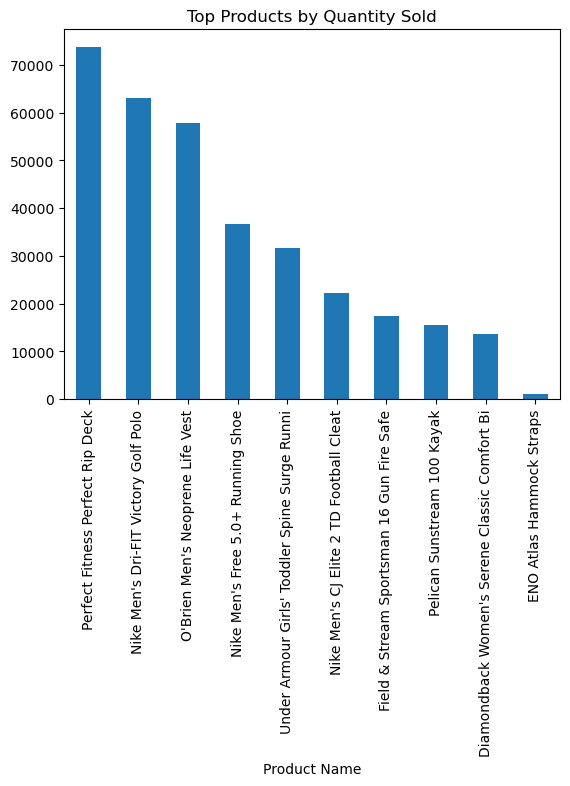

In [62]:
top_products = df.groupby("Product Name")["Order Item Quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top Products by Quantity Sold")
plt.show()

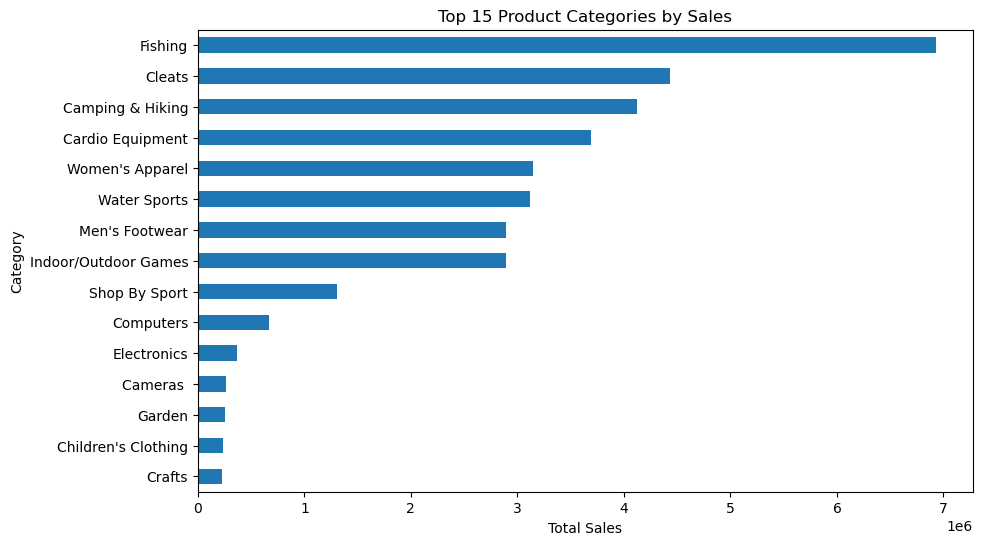

In [42]:
plt.figure(figsize=(10,6))

category_sales = (
    df.groupby("Category Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

category_sales.plot(kind="barh")

plt.title("Top 15 Product Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.show()

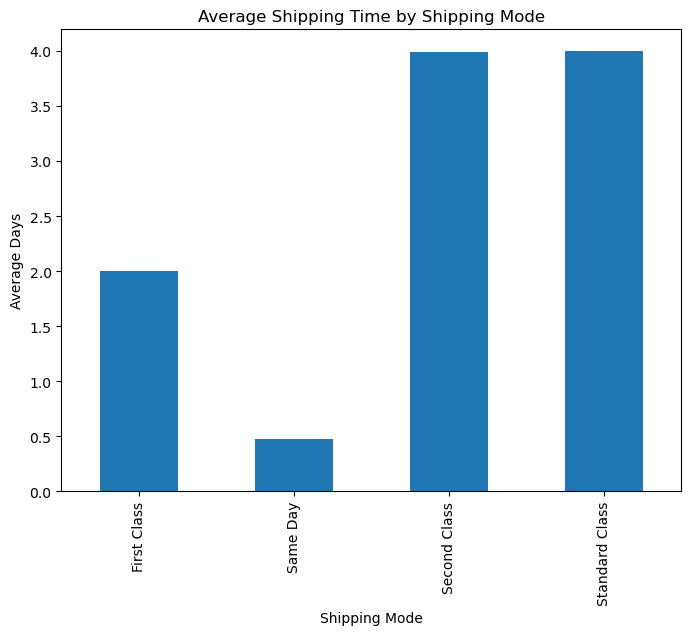

In [35]:
plt.figure(figsize=(8,6))

shipping = df.groupby("Shipping Mode")["Days for shipping (real)"].mean()

shipping.plot(kind="bar")

plt.title("Average Shipping Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Days")

plt.show()

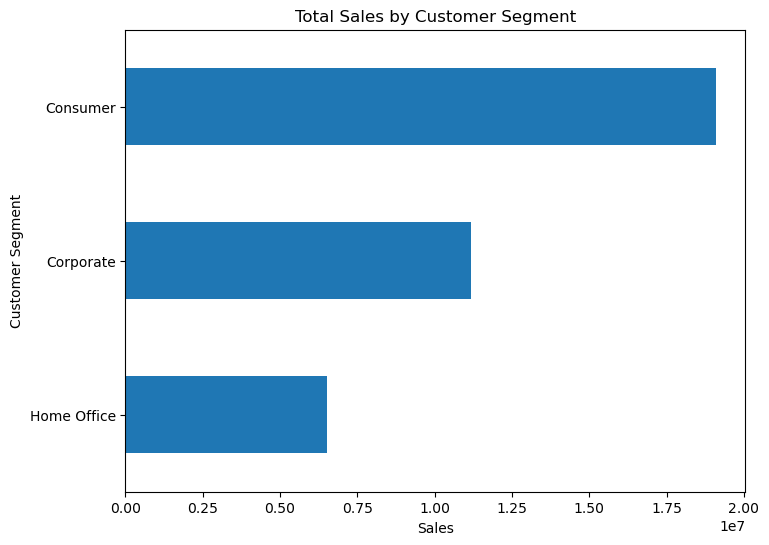

In [36]:
plt.figure(figsize=(8,6))

segment_sales = df.groupby("Customer Segment")["Sales"].sum().sort_values()

segment_sales.plot(kind="barh")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Sales")
plt.ylabel("Customer Segment")

plt.show()

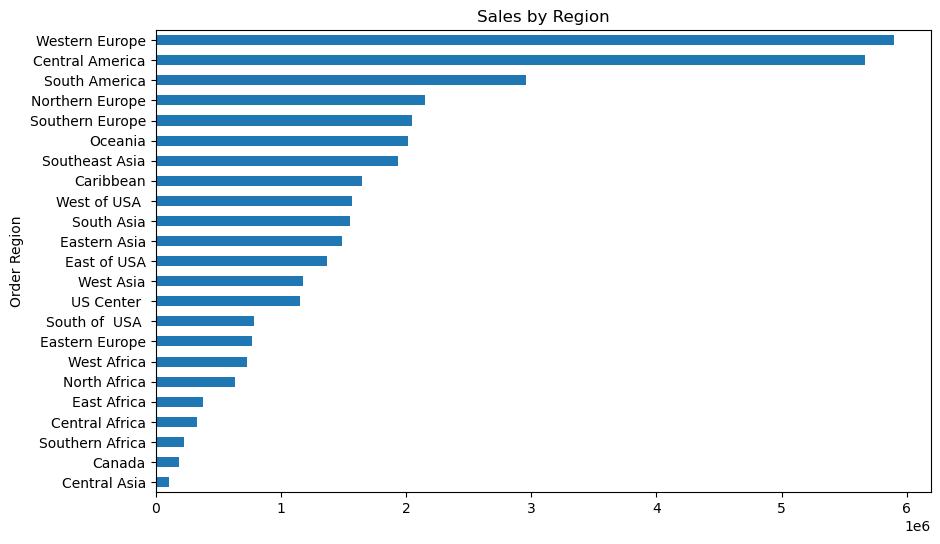

In [16]:
sales_region = df.groupby("Order Region")["Sales"].sum().sort_values()

sales_region.plot(kind="barh", figsize=(10,6))
plt.title("Sales by Region")
plt.show()


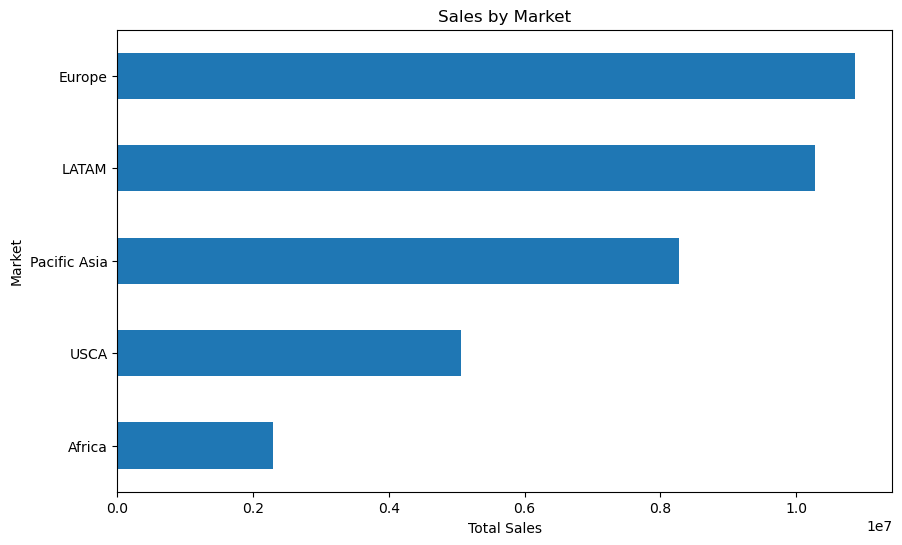

In [39]:
plt.figure(figsize=(10,6))

market_sales = df.groupby("Market")["Sales"].sum().sort_values()

market_sales.plot(kind="barh")

plt.title("Sales by Market")
plt.xlabel("Total Sales")

plt.show()

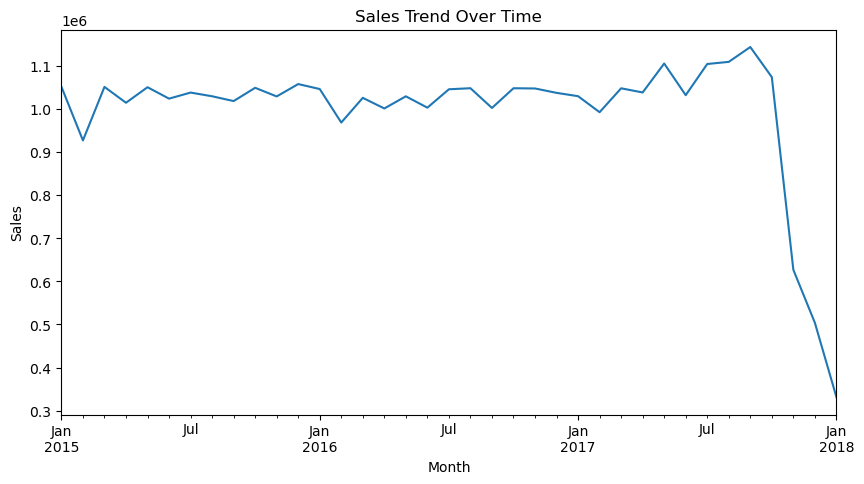

In [15]:
sales_month = df.groupby(
    df["order date (DateOrders)"].dt.to_period("M")
)["Sales"].sum()

sales_month.plot(figsize=(10,5))

plt.title("Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

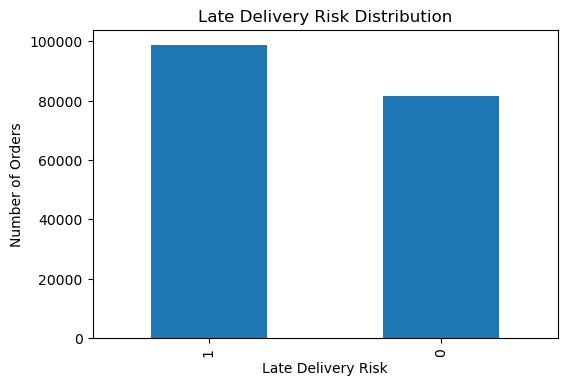

In [37]:
plt.figure(figsize=(6,4))

df["Late_delivery_risk"].value_counts().plot(kind="bar")

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.show()

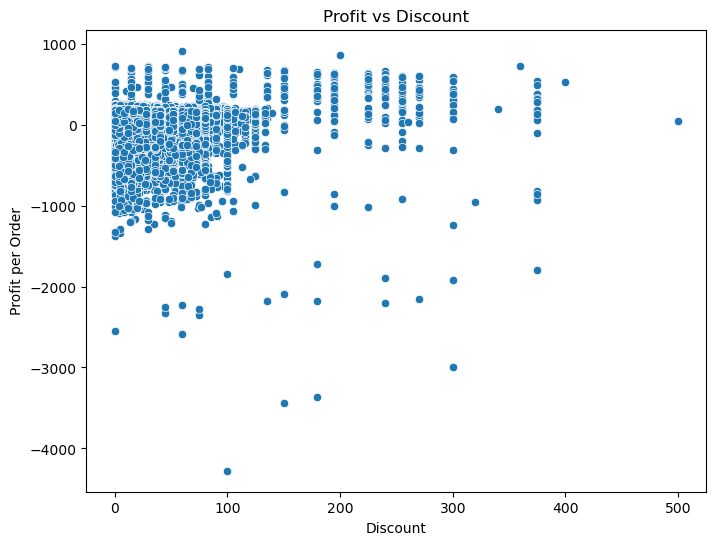

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Order Item Discount",
    y="Benefit per order"
)

plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit per Order")

plt.show()

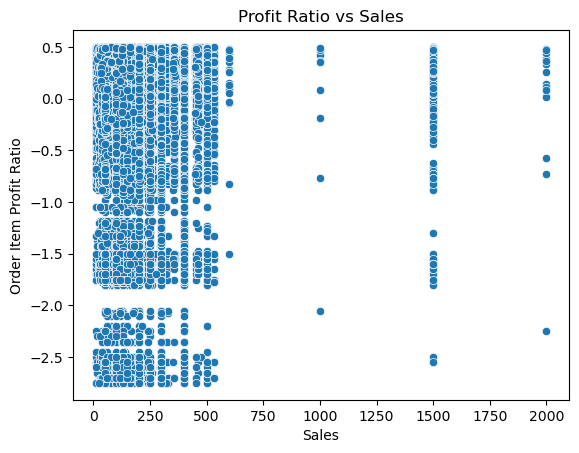

In [69]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Order Item Profit Ratio",
    alpha=0.4
)

plt.title("Profit Ratio vs Sales")
plt.xlabel("Sales")
plt.ylabel("Profit Ratio")

plt.show()

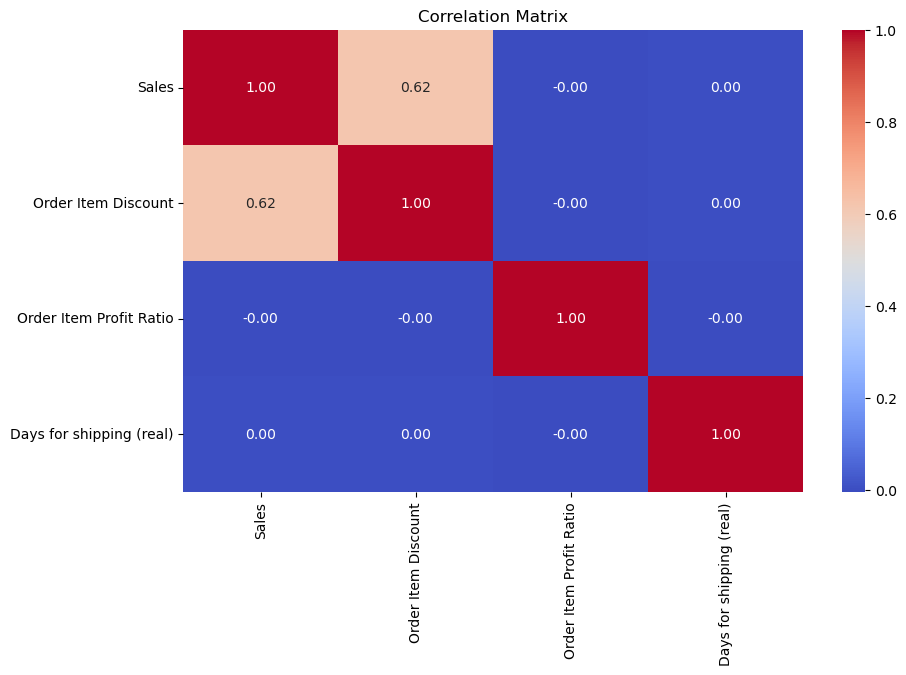

In [34]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[["Sales","Order Item Discount","Order Item Profit Ratio","Days for shipping (real)"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()